In [1]:
import pandas as pd

# Cargamos el archivo limpio
try:
    df_cleaned = pd.read_parquet('../data/processed/ecommerce_sales_cleaned.parquet')
except:
    df_cleaned = pd.read_csv('../data/processed/ecommerce_sales_cleaned.csv')

# Comprobamos que las nuevas columnas siguen ahí
df_cleaned.head(2)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month_num,month_name,day_of_week
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.2,2022,1,January,Saturday
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.1,2022,1,January,Sunday


In [2]:
# Agrupamos por número y nombre de mes, sumamos la columna 'revenue'
ventas_por_mes = df_cleaned.groupby(['month_num', 'month_name'])['revenue'].sum().reset_index()

# Ordenamos de mayor a menor ingreso
ventas_por_mes_ranking = ventas_por_mes.sort_values(by='revenue', ascending=False)

print("--- Ranking de Ventas por Mes ---")
display(ventas_por_mes_ranking)

--- Ranking de Ventas por Mes ---


,month_num,month_name,revenue
4,5,May,479772.55
7,8,August,460874.78
5,6,June,442941.58
6,7,July,440570.72
0,1,January,426374.92
2,3,March,425050.52
1,2,February,413890.24
10,11,November,410657.88
9,10,October,407873.12
8,9,September,402368.11


In [3]:
# 1. Agrupamos por el día de la semana y sumamos los ingresos
ventas_por_dia = df_cleaned.groupby('day_of_week')['revenue'].sum().reset_index()

# 2. Creamos un orden lógico de lunes a domingo para que el análisis tenga sentido cronológico
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_por_dia['day_of_week'] = pd.Categorical(ventas_por_dia['day_of_week'], categories=orden_dias, ordered=True)

# 3. Ordenamos la tabla según el orden de los días de la semana
ventas_por_dia_cronologico = ventas_por_dia.sort_values('day_of_week')

print("--- Ingresos Totales por Día de la Semana ---")
display(ventas_por_dia_cronologico)

--- Ingresos Totales por Día de la Semana ---


,day_of_week,revenue
1,Monday,729466.69
5,Tuesday,742856.04
6,Wednesday,727338.13
4,Thursday,694328.93
0,Friday,730978.26
2,Saturday,758305.90
3,Sunday,726501.79


In [4]:
# Agrupamos por categoría de producto, sumamos ingresos y contamos cuántos artículos se vendieron
productos_analisis = df_cleaned.groupby('product_category').agg(
    Ingresos_Totales=('revenue', 'sum'),
    Cantidad_Vendida=('quantity', 'sum'),
    Precio_Medio=('unit_price', 'mean')
).reset_index()

# Ordenamos por ingresos de mayor a menor
productos_ranking = productos_analisis.sort_values(by='Ingresos_Totales', ascending=False)

print("--- Rendimiento por Categoría de Producto ---")
display(productos_ranking)

--- Rendimiento por Categoría de Producto ---


,product_category,Ingresos_Totales,Cantidad_Vendida,Precio_Medio
2,Electronics,1829899.22,7109,314.902656
1,Clothing,1531931.72,6171,304.010901
3,Home,982083.92,3949,306.257730
0,Beauty,765860.88,2995,304.712891


In [5]:
# 1. Agrupamos por cada pedido único (order_id) y sumamos su revenue 
# (Por si un cliente compró varios productos en un mismo pedido)
total_por_pedido = df_cleaned.groupby('order_id')['revenue'].sum()

# 2. Calculamos la media de todos los pedidos
ticket_medio = total_por_pedido.mean()

print("--- Métricas Clave de Facturación ---")
print(f"El Ticket Medio por pedido es de: ${ticket_medio:.2f}")
print(f"El pedido más caro fue de: ${total_por_pedido.max():.2f}")
print(f"El pedido más barato fue de: ${total_por_pedido.min():.2f}")

--- Métricas Clave de Facturación ---
El Ticket Medio por pedido es de: $1021.96
El pedido más caro fue de: $4119.33
El pedido más barato fue de: $11.21


In [6]:
# Agrupamos por región y calculamos el total de ingresos y la nota media de satisfacción
analisis_region = df_cleaned.groupby('region').agg(
    Ventas_Totales=('revenue', 'sum'),
    Satisfaccion_Media=('customer_rating', 'mean'),
    Total_Pedidos=('order_id', 'count')
).reset_index()

# Ordenamos por ventas totales de mayor a menor
analisis_region_ranking = analisis_region.sort_values(by='Ventas_Totales', ascending=False)

print("--- Análisis de Rendimiento por Región ---")
display(analisis_region_ranking)

--- Análisis de Rendimiento por Región ---


,region,Ventas_Totales,Satisfaccion_Media,Total_Pedidos
3,West,1345582.16,2.961521,1289
1,North,1281508.45,2.993182,1276
2,South,1246640.90,2.967798,1208
0,East,1236044.23,2.973187,1227


In [7]:
%pip install matplotlib seaborn pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


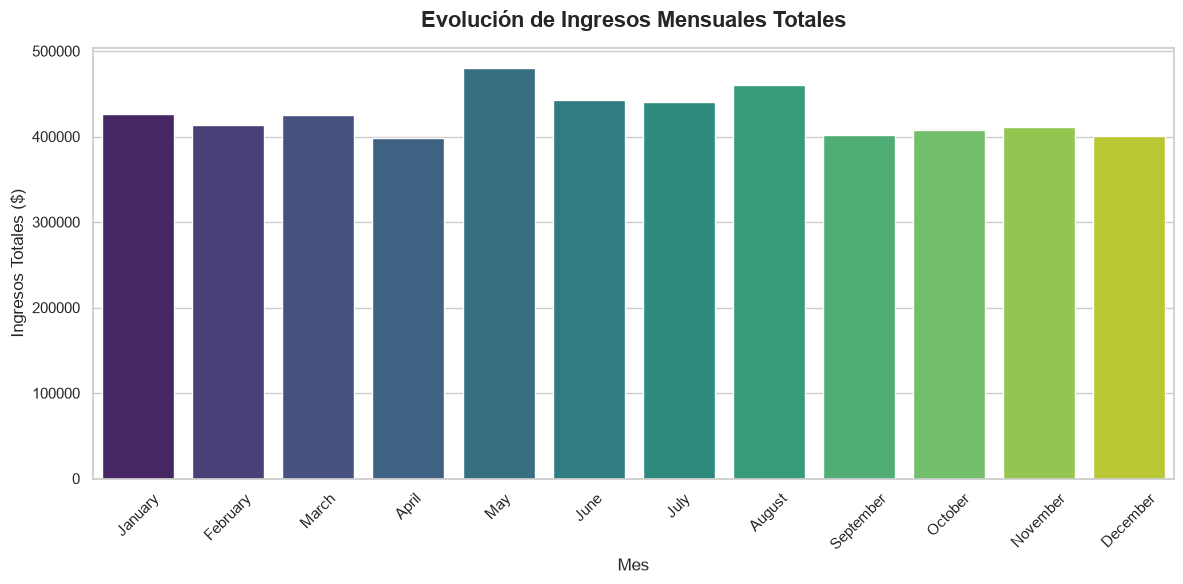

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Crear un gráfico de barras para ver la evolución cronológica
# Usamos 'ventas_por_mes'
sns.barplot(
    x='month_name', 
    y='revenue', 
    data=ventas_por_mes, 
    palette='viridis',
    hue='month_name',
    legend=False
)

# 3. Personalizar títulos y etiquetas para que sea profesional
plt.title('Evolución de Ingresos Mensuales Totales', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.xticks(rotation=45) # Inclina los nombres de los meses para que no se solapen

# 4. Ajustar el diseño y mostrarlo
plt.tight_layout()
plt.show()